In [ ]:
from langchain_openai import AzureChatOpenAI
from langchain_ollama import ChatOllama
from pydantic import BaseModel, Field
from dotenv import load_dotenv
load_dotenv()

In [ ]:
import os
from pyprojroot import here

os.chdir(here())

In [ ]:
from coeur.score import Coeur
from coeur.utils.dataloader import UserStoryDataset

import pandas as pd
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from bert_score import score as bert_score

In [ ]:
from datetime import datetime
from pathlib import Path
import json
import numpy as np

# Utils

In [ ]:
# llm = AzureChatOpenAI(
#     azure_deployment="gpt-4.1",
#     api_version="2025-01-01-preview",
#     temperature=0,
#     max_tokens=2000,
#     timeout=None,
#     max_retries=2
# )

llm = ChatOllama(
    model="mistral-small:22b",
    temperature=0,
    max_tokens=2000,
    timeout=30,
    max_retries=3
)

In [ ]:
llm.invoke("Hello, world!")

AIMessage(content=" Hello! How can I assist you today? Let's have a friendly chat. 😊", additional_kwargs={}, response_metadata={'model': 'mistral-small:22b', 'created_at': '2026-03-27T00:00:32.904853159Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1699626601, 'load_duration': 1478777799, 'prompt_eval_count': 9, 'prompt_eval_duration': 37829136, 'eval_count': 20, 'eval_duration': 178378589, 'logprobs': None, 'model_name': 'mistral-small:22b', 'model_provider': 'ollama'}, id='lc_run--019d2c97-ade1-75d3-99db-7b37fbfa4361-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 20, 'total_tokens': 29})

In [ ]:
class Interesting(BaseModel):
     interesting: bool = Field(
        description="Indicates whether the input text is valuable to write a user story or not. True if it is valuable, False otherwise."
    )

class UserStory(BaseModel):
    description: str = Field(
        min_length=20,
        # Looser pattern: just requires "As a" start and "I want" somewhere in the text
        # pattern=r"^As an? .+",
        examples=[
            "As a user, I want to log in, so that I can access my profile.",
            "As a product owner, I want to prioritize the backlog, so that the team works on the most valuable tasks."
        ],
        description="A user story is a description of a feature from an end-user perspective." + \
            "It should follow the 'As a [role], I want [feature], so that [benefit]' format." + \
            "Additionnaly, it should be between 20 and 500 characters long." 
    )

In [ ]:
specs_path = os.path.join('datasets', 'trident', 'trident_specs.pdf')
backlog_path = os.path.join('datasets', 'trident', 'trident_backlog.csv')
dataset_names = ["trident"]

# ICL Experiment

We provide the model with $d$ the project context (including epics), and $s'_d$ user stories from the same epic story as $\text{us}_i$. We setup four experiments:
1. Context ($d$) and related user stories ($s'_d$)
2. No context ($d$) and no related user stories ($s'_d$)
3. Context-only ($d$)
4. Epic-only ($s'_d$)

In [ ]:
coeur = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True, penalize_duplicates=True)

R, B = coeur.load_data(ref_path=specs_path, cand_path=backlog_path, ref_mode="pdf", cand_mode="csv")

print(f"Reference length: {len(R)} chars")
print(f"Total stories: {len(B)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Reference length: 6964 chars
Total stories: 52


In [ ]:
trident = UserStoryDataset(dataset_names)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 0. Helpers

In [ ]:
MAX_RETRIES = 5

def generate_B_alt(dataset: UserStoryDataset, llm: AzureChatOpenAI, prompt: str = ""):
    y_pred = []
    for i in tqdm(range(len(dataset))):
        specs, user_story, related_user_stories, epic = dataset[i][0], dataset[i][1], dataset[i][2], dataset[i][3]

        retries = 0
        response = None
        while retries < MAX_RETRIES:
            try:
                response = llm.with_structured_output(UserStory).invoke(
                    prompt.format(
                        epic=epic,
                        specs=specs,
                        related_user_stories=related_user_stories
                    )
                )
                break  # Success - exit retry loop
            except Exception as e:
                retries += 1
                print(f"User Story Generation Error (attempt {retries}/{MAX_RETRIES}): {e}")
                if retries >= MAX_RETRIES:
                    # Fallback: generate without structured output and format manually
                    print(f"Warning: Max retries reached for story {i}. Using raw LLM output.")
                    raw_response = llm.invoke(
                        prompt.format(
                            epic=epic,
                            specs=specs,
                            related_user_stories=related_user_stories
                        )
                    )
                    # Try to extract/format a user story from the raw response
                    raw_text = raw_response.content.strip()
                    if not raw_text.startswith("As a"):
                        raw_text = f"As a user, I want {raw_text[:200]}"
                    response = UserStory.model_construct(description=raw_text)

        y_pred.append({"epic": epic, "user_story": response.description, "true_user_story": user_story})
    B_pred = pd.DataFrame(y_pred)
    return B_pred

In [ ]:
def iterative_coeur(B: pd.DataFrame, cs_offset=10, sigma="ROUGE-2 Precision", l="s"):
    # Iterative Calculation
    results = []
    coeur = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True)

    for i in tqdm(range(cs_offset, len(B) + 1)):
        current_backlog = B.iloc[:i]
        
        scores = coeur.score(R=R, B=current_backlog, sigma=sigma, l=l)
        scores['n_stories'] = i
        results.append(scores)
        
    # Create DataFrame from results
    df_results = pd.DataFrame(results)
    return df_results

def plot_iterative_coeur(df_results):
    plt.figure(figsize=(10, 6))
    plt.plot(df_results['n_stories'], df_results['COEUR'], label='COEUR', marker='o', markersize=3)
    plt.plot(df_results['n_stories'], df_results['Cohesion'], label='Cohesion', linestyle='--')
    plt.plot(df_results['n_stories'], df_results['Exhaustiveness'], label='Exhaustiveness', linestyle='--')

    plt.xlabel('Number of User Stories')
    plt.ylabel('Score')
    plt.title('COEUR Evolution with Increasing Backlog Size')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_multiple_iterative_coeur(mean_results, std_results):
    plt.figure(figsize=(10, 6))
    plt.plot(mean_results['n_stories'], mean_results['COEUR'], label='COEUR', marker='o', markersize=3)
    plt.fill_between(mean_results['n_stories'],
                     mean_results['COEUR'] - std_results['COEUR'],
                     mean_results['COEUR'] + std_results['COEUR'],
                     alpha=0.2)

    plt.plot(mean_results['n_stories'], mean_results['Cohesion'], label='Cohesion', linestyle='--')
    plt.fill_between(mean_results['n_stories'],
                     mean_results['Cohesion'] - std_results['Cohesion'],
                     mean_results['Cohesion'] + std_results['Cohesion'],
                     alpha=0.2)

    plt.plot(mean_results['n_stories'], mean_results['Exhaustiveness'], label='Exhaustiveness', linestyle='--')
    plt.fill_between(mean_results['n_stories'],
                     mean_results['Exhaustiveness'] - std_results['Exhaustiveness'],
                     mean_results['Exhaustiveness'] + std_results['Exhaustiveness'],
                     alpha=0.2)

    plt.xlabel('Number of User Stories')
    plt.ylabel('Score')
    plt.title('COEUR Evolution with Increasing Backlog Size')
    plt.legend()
    plt.grid(True)
    plt.show()

def load_results(dataset_name: str, strategy_name: str):
    results_dir = os.path.join('experiments', 'llm_validation', 'output', dataset_name)

    mean_path = os.path.join(results_dir, f'mean_results_{strategy_name}.csv')
    std_path = os.path.join(results_dir, f'std_results_{strategy_name}.csv')

    mean_results = pd.read_csv(mean_path)
    std_results = pd.read_csv(std_path)
    return mean_results, std_results

def compare_coeur_strategies(dataset_name: str, strategy_names: list[str], metric: str = "COEUR"):
    plt.figure(figsize=(10, 6))

    for strategy_name in strategy_names:
        mean_results, std_results = load_results(dataset_name, strategy_name)
        
        plt.plot(mean_results['n_stories'], mean_results[metric], label=strategy_name, marker='o', markersize=3)
        plt.fill_between(mean_results['n_stories'],
                         mean_results[metric] - std_results[metric],
                         mean_results[metric] + std_results[metric],
                         alpha=0.2)

    plt.xlabel('Number of User Stories')
    plt.ylabel(f'{metric} Score')
    plt.title(f'Comparison of {metric} Evolution Across Strategies')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def evaluate_and_plot(B_pred: pd.DataFrame, R: str, B_true: pd.DataFrame = None):
    # Imports
    from rouge_score import rouge_scorer
    import numpy as np
    
    # 1. ROUGE Scores Calculation (Row-by-row: Generated vs True User Story)
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = []
    
    for _, row in B_pred.iterrows():
        # Reference is true_user_story, Hypothesis is generated user_story
        scores = scorer.score(row['true_user_story'], row['user_story'])
        rouge_scores.append({
            'rouge1': scores['rouge1'].fmeasure,
            'rouge2': scores['rouge2'].fmeasure,
            'rougeL': scores['rougeL'].fmeasure
        })
    
    avg_rouge = pd.DataFrame(rouge_scores).mean()
    
    # 2. COEUR Scores Calculation (Full Backlog: Generated vs Specs)
    coeur = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True)
    
    # Calculate COEUR for generated backlog
    scores_pred = coeur.score(R=R, B=B_pred, sigma="ROUGE-2 F1", l="b")
    
    # Calculate COEUR for true backlog if provided for comparison
    scores_true = None
    if B_true is not None:
         scores_true = coeur.score(R=R, B=B_true, sigma="ROUGE-2 F1", l="b")

    # 3. Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Helper for bar labels
    def autolabel(ax, rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

    # --- Plot 1: ROUGE Scores ---
    rouge_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
    rouge_values = [avg_rouge['rouge1'], avg_rouge['rouge2'], avg_rouge['rougeL']]
    
    x_rouge = np.arange(len(rouge_labels))
    width = 0.35
    
    rects_rouge = ax1.bar(x_rouge, rouge_values, width * 1.5, label='Generated vs True', color='#1f77b4')
    
    ax1.set_ylabel('F1 Score')
    ax1.set_title('Evaluation 1: Textual Similarity\n(Generated Story vs True Story)')
    ax1.set_xticks(x_rouge)
    ax1.set_xticklabels(rouge_labels)
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    autolabel(ax1, rects_rouge)

    # --- Plot 2: COEUR Scores ---
    coeur_labels = ['COEUR', 'Cohesion', 'Exhaustiveness']
    pred_values = [scores_pred['COEUR'], scores_pred['Cohesion'], scores_pred['Exhaustiveness']]
    
    x_coeur = np.arange(len(coeur_labels))
    
    if scores_true:
        true_values = [scores_true['COEUR'], scores_true['Cohesion'], scores_true['Exhaustiveness']]
        rects1 = ax2.bar(x_coeur - width/2, pred_values, width, label='Generated Backlog')
        rects2 = ax2.bar(x_coeur + width/2, true_values, width, label='Ground Truth Backlog', color='lightgray')
        ax2.legend() 
        autolabel(ax2, rects1)
        autolabel(ax2, rects2)
    else:
        rects = ax2.bar(x_coeur, pred_values, width, label='Generated Backlog')
        autolabel(ax2, rects)
        
    ax2.set_xticks(x_coeur)
    ax2.set_xticklabels(coeur_labels)
    ax2.set_title('Evaluation 2: Backlog Quality Metrics\n(Backlog vs Specs)')
    ax2.set_ylabel('Score')
    ax2.set_ylim(0, 1.05)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return avg_rouge, scores_pred


def evaluate_and_compare(strategies: dict, R: str, B_true: pd.DataFrame = None,
                         sigma="ROUGE-2 F1", l="b", lmbd=0.75, use_bertscore=True):
    """
    Evaluate and compare multiple user story generation strategies.
    
    Args:
        strategies: Dictionary of {name: DataFrame} with generated backlogs
        R: Reference specifications text
        B_true: Ground truth backlog DataFrame (optional)
        sigma: Similarity metric for COEUR scoring
        l: Level parameter for COEUR scoring
        lmbd: Lambda parameter for COEUR scoring
        use_bertscore: Whether to compute BERTScore (slower but more semantic)
    
    Returns:
        Tuple of (rouge_results, bertscore_results, coeur_results)
    """
    # Imports
    from rouge_score import rouge_scorer
    import numpy as np
    
    # Initialize scorers
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    coeur_scorer = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True, penalize_duplicates=True)
    
    rouge_results = {}
    bertscore_results = {}
    coeur_results = {}
    
    # 1. Calculation Loop
    for name, B_pred in strategies.items():
        # Collect references and candidates for batch processing
        references = []
        candidates = []
        
        # ROUGE Scores
        rouge_scores = []
        for _, row in B_pred.iterrows():
            # Ensure we have a reference. Using 'true_user_story' from generate_B_alt
            ref = row.get('true_user_story', "")
            if not ref and B_true is not None:
                # Fallback if indices align
                try: ref = B_true.iloc[_]['user_story']
                except: pass
                
            if ref:
                references.append(ref)
                candidates.append(row['user_story'])
                scores = scorer.score(ref, row['user_story'])
                rouge_scores.append({
                    'rouge1': scores['rouge1'].fmeasure,
                    'rouge2': scores['rouge2'].fmeasure,
                    'rougeL': scores['rougeL'].fmeasure
                })
        
        if rouge_scores:
            rouge_results[name] = pd.DataFrame(rouge_scores).mean()
        
        # BERTScore Calculation (batch for efficiency)
        if use_bertscore and references and candidates:
            
            P, R_bert, F1 = bert_score(candidates, references, lang="en", verbose=False)
            bertscore_results[name] = {
                'precision': P.mean().item(),
                'recall': R_bert.mean().item(),
                'f1': F1.mean().item()
            }
        
        # COEUR Scores
        coeur_results[name] = coeur_scorer.score(R=R, B=B_pred, sigma=sigma, l=l, lmbd=lmbd)
        
    # Ground Truth COEUR
    coeur_true = None
    if B_true is not None:
         coeur_true = coeur_scorer.score(R=R, B=B_true, sigma=sigma, l=l, lmbd=lmbd)

    # 2. Visualization
    n_plots = 3 if use_bertscore and bertscore_results else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 8))
    if n_plots == 2:
        ax1, ax2 = axes
        ax_bert = None
    else:
        ax1, ax_bert, ax2 = axes
    
    size_offset = 4
    # Set global font sizes
    plt.rc('font', size=12+size_offset)
    plt.rc('axes', titlesize=16+size_offset)
    plt.rc('axes', labelsize=14+size_offset)
    plt.rc('xtick', labelsize=12+size_offset)
    plt.rc('ytick', labelsize=12+size_offset)
    plt.rc('legend', fontsize=12+size_offset)

    def autolabel(ax, rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', rotation=90, fontsize=9)

    # --- Plot 1: ROUGE ---
    if rouge_results:
        metrics = ['rouge1', 'rouge2', 'rougeL']
        plot_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
        x = np.arange(len(plot_labels))
        width = 0.8 / len(strategies)
        
        for i, (name, res) in enumerate(rouge_results.items()):
            offset = width * i - width * (len(strategies) - 1) / 2
            values = [res[m] for m in metrics]
            rects = ax1.bar(x + offset, values, width, label=name)
            autolabel(ax1, rects)
            
        ax1.set_ylabel('F1 Score')
        ax1.set_title('ROUGE: Textual Similarity vs Ground Truth')
        ax1.set_xticks(x)
        ax1.set_xticklabels(plot_labels)
        ax1.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2) 
        ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # --- Plot 2: BERTScore ---
    if ax_bert is not None and bertscore_results:
        metrics_bert = ['precision', 'recall', 'f1']
        plot_labels_bert = ['Precision', 'Recall', 'F1']
        x_bert = np.arange(len(plot_labels_bert))
        width_bert = 0.8 / len(strategies)
        
        for i, (name, res) in enumerate(bertscore_results.items()):
            offset = width_bert * i - width_bert * (len(strategies) - 1) / 2
            values = [res[m] for m in metrics_bert]
            rects = ax_bert.bar(x_bert + offset, values, width_bert, label=name)
            autolabel(ax_bert, rects)
            
        ax_bert.set_ylabel('Score')
        ax_bert.set_title('BERTScore: Semantic Similarity vs Ground Truth')
        ax_bert.set_xticks(x_bert)
        ax_bert.set_xticklabels(plot_labels_bert)
        ax_bert.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2) 
        ax_bert.grid(axis='y', linestyle='--', alpha=0.3)

    # --- Plot 3: COEUR ---
    metrics_c = ['COEUR', 'Cohesion', 'Exhaustiveness']
    x_c = np.arange(len(metrics_c))
    num_groups = len(strategies) + (1 if coeur_true else 0)
    width_c = 0.8 / num_groups
    
    for i, (name, res) in enumerate(coeur_results.items()):
        offset = width_c * i - width_c * (num_groups - 1) / 2
        values = [res[m] for m in metrics_c]
        rects = ax2.bar(x_c + offset, values, width_c, label=name)
        autolabel(ax2, rects)
        
    if coeur_true:
        offset = width_c * len(strategies) - width_c * (num_groups - 1) / 2
        values = [coeur_true[m] for m in metrics_c]
        rects = ax2.bar(x_c + offset, values, width_c, label='Ground Truth', color='gray', alpha=0.3, hatch='//')
        autolabel(ax2, rects)

    ax2.set_ylabel('Score')
    ax2.set_title('COEUR: Backlog Quality Metrics')
    ax2.set_xticks(x_c)
    ax2.set_xticklabels(metrics_c)
    ax2.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2)
    ax2.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.25)
    plt.show()
    
    return rouge_results, bertscore_results, coeur_results

# Comparative Analysis

### Helpers

In [ ]:
def load_experiment(experiment_folder):
    path = Path(experiment_folder)
    results = {}
    
    # Load all json files that aren't metadata
    for file in path.glob("strategy_*.json"):
        strategy_name = file.stem.replace("strategy_", "")
        results[strategy_name] = pd.read_json(file)
    desired_order = ["context_related", "context_only", "related_only", "no_context_no_epic"]
    results = {k: results[k] for k in desired_order if k in results}

    return results

def save_strategies(strategies, prompts, experiment_folder, experiment_name=None):
    """
    Saves a dictionary of strategy DataFrames and their corresponding prompts.
    """
    # 1. Create a unique folder for this run
    if experiment_name is None:
        experiment_name = f"run_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    
    base_path = Path("experiments/llm_validation/output") / experiment_folder / experiment_name
    base_path.mkdir(parents=True, exist_ok=True)
    
    # 2. Save each strategy DataFrame
    for name, df in strategies.items():
        # Use Parquet or JSONL for text data (CSVs can be buggy with long text)
        file_path = base_path / f"strategy_{name}.json"
        df.to_json(file_path, orient="records", indent=4)
        print(f"Saved strategy '{name}' to {file_path}")

    # 3. Save the prompts (Metadata) so you know what generated the data
    metadata = {
        "timestamp": datetime.now().isoformat(),
        "prompts": prompts,
        "strategy_names": list(strategies.keys())
    }
    
    with open(base_path / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=4)
    
    print(f"\n✅ Experiment saved in: {base_path}")
    return base_path

### Utils

In [ ]:
context_related_prompt = """
# Your Task:
Generate a user story faithful to the epic story title, the specifications chunk and related user stories (from the same epic story) that you have.

# Input to your disposal:

### Software Specifications Chunk :
{specs}

### Related User Stories :
{related_user_stories}

### Epic Story Title :
{epic}

# Output Expected:
A user story fitting the epic, specifications chunk and related user stories, following the 'As a [role], I want [feature], so that [value]' format.
"""

no_context_no_related_prompt = """
Generate a user story based on the theme of your choice.
"""

context_only_prompt = """
# Your Task:
Generate a user story faithful to the specifications chunk that you have.

# Input to your disposal:

### Software Specifications Chunk :
{specs}

# Output Expected:
A user story fitting the specifications chunk, following the 'As a [role], I want [feature], so that [value]' format.
"""

related_only_prompt = """
# Your Task:
Generate a user story faithful to the epic title that you have.

# Input to your disposal:

### Epic Story Title :
{epic}

# Output Expected:
A user story fitting the epic title, following the 'As a [role], I want [feature], so that [value]' format.
"""

In [ ]:
trident = UserStoryDataset(["trident"])
retro = UserStoryDataset(["retro"])
alfred = UserStoryDataset(["alfred"])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
prompts = {
    "context_related": context_related_prompt,
    "context_only": context_only_prompt,
    "related_only": related_only_prompt,
    "no_context_no_epic": no_context_no_related_prompt,
}

In [ ]:
SIGMA = "ROUGE-2 Precision"
L = "s"
LMBD = 0.75

In [ ]:
coeur = Coeur(random_state=42, lemmatization=True, remove_stopwords=True, stemming=True,
              remove_re_se_stopwords=True, penalize_duplicates=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Trident Dataset

In [ ]:
specs_path = os.path.join('datasets', 'trident', 'trident_specs.pdf')
backlog_path = os.path.join('datasets', 'trident', 'trident_backlog.csv')
R_TRIDENT, B_TRIDENT = coeur.load_data(ref_path=specs_path, cand_path=backlog_path, ref_mode="pdf", cand_mode="csv")

In [ ]:
strategies = {}
for name, prompt in prompts.items():
    B_pred = generate_B_alt(trident, llm,
                        prompt=prompt)
    strategies[name] = B_pred



  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

  0%|          | 0/52 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


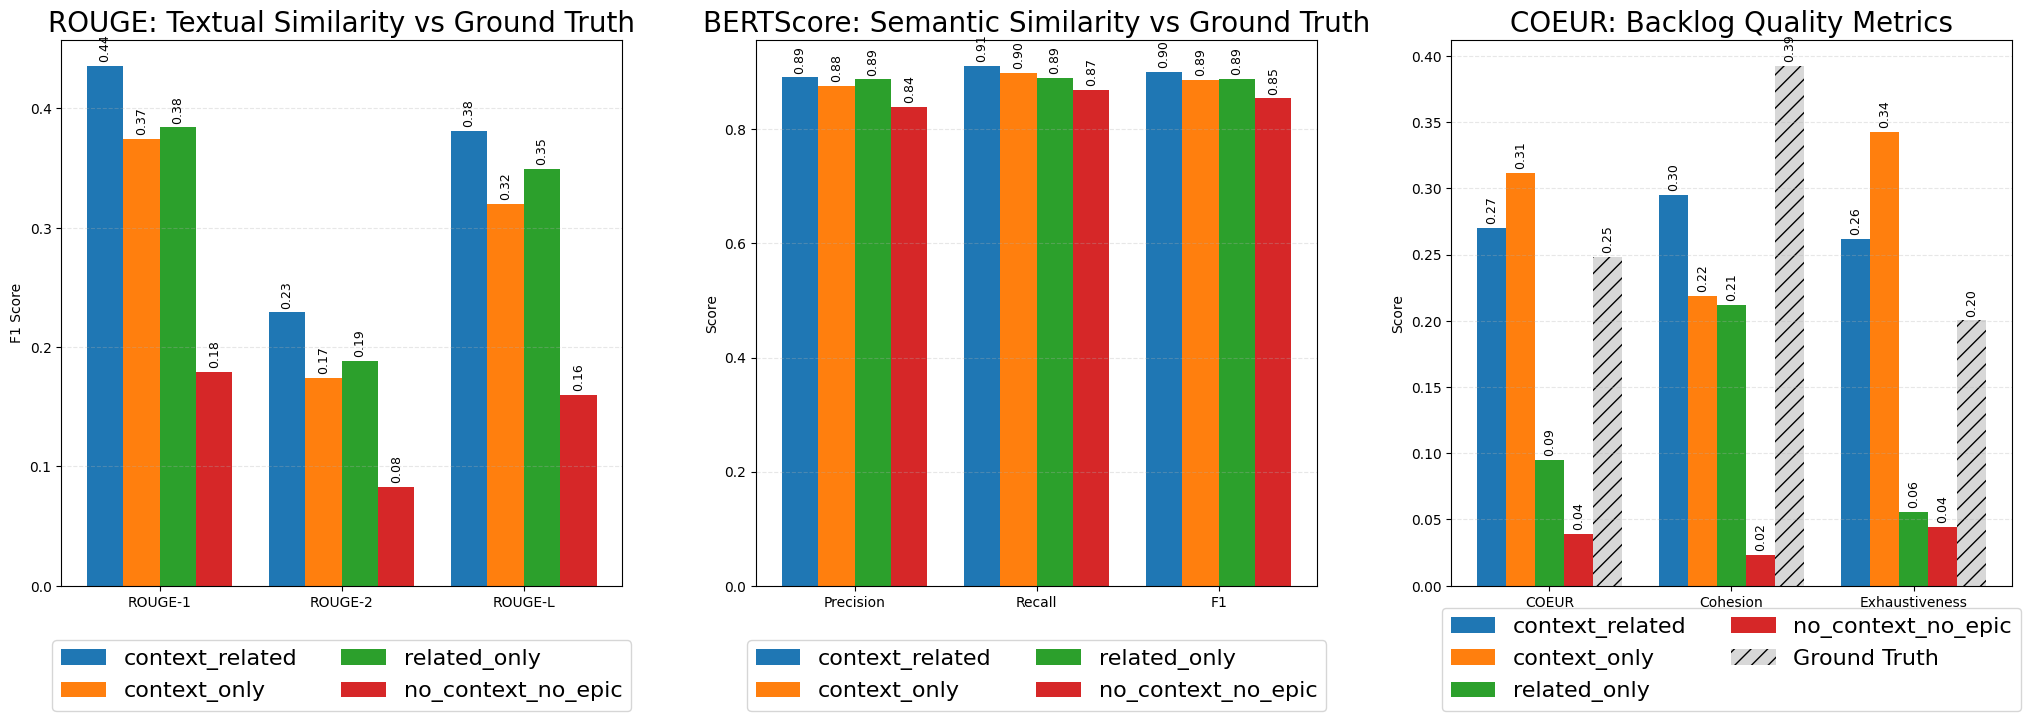

In [ ]:
_ = evaluate_and_compare(strategies, R_TRIDENT, B_true=B_TRIDENT,
                         sigma=SIGMA, l=L, lmbd=LMBD)

In [ ]:
save_strategies(strategies, prompts, "icl_trident", "mistral_small_22b")

Saved strategy 'context_related' to experiments/llm_validation/output/icl_trident/mistral_small_22b/strategy_context_related.json
Saved strategy 'context_only' to experiments/llm_validation/output/icl_trident/mistral_small_22b/strategy_context_only.json
Saved strategy 'related_only' to experiments/llm_validation/output/icl_trident/mistral_small_22b/strategy_related_only.json
Saved strategy 'no_context_no_epic' to experiments/llm_validation/output/icl_trident/mistral_small_22b/strategy_no_context_no_epic.json

✅ Experiment saved in: experiments/llm_validation/output/icl_trident/mistral_small_22b


PosixPath('experiments/llm_validation/output/icl_trident/mistral_small_22b')

### Retro Dataset

In [ ]:
specs_path = os.path.join('datasets', 'retro', 'retro_specs.pdf')
backlog_path = os.path.join('datasets', 'retro', 'retro_backlog.csv')
R_RETRO, B_RETRO = coeur.load_data(ref_path=specs_path, cand_path=backlog_path, ref_mode="pdf", cand_mode="csv")

  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

  0%|          | 0/92 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


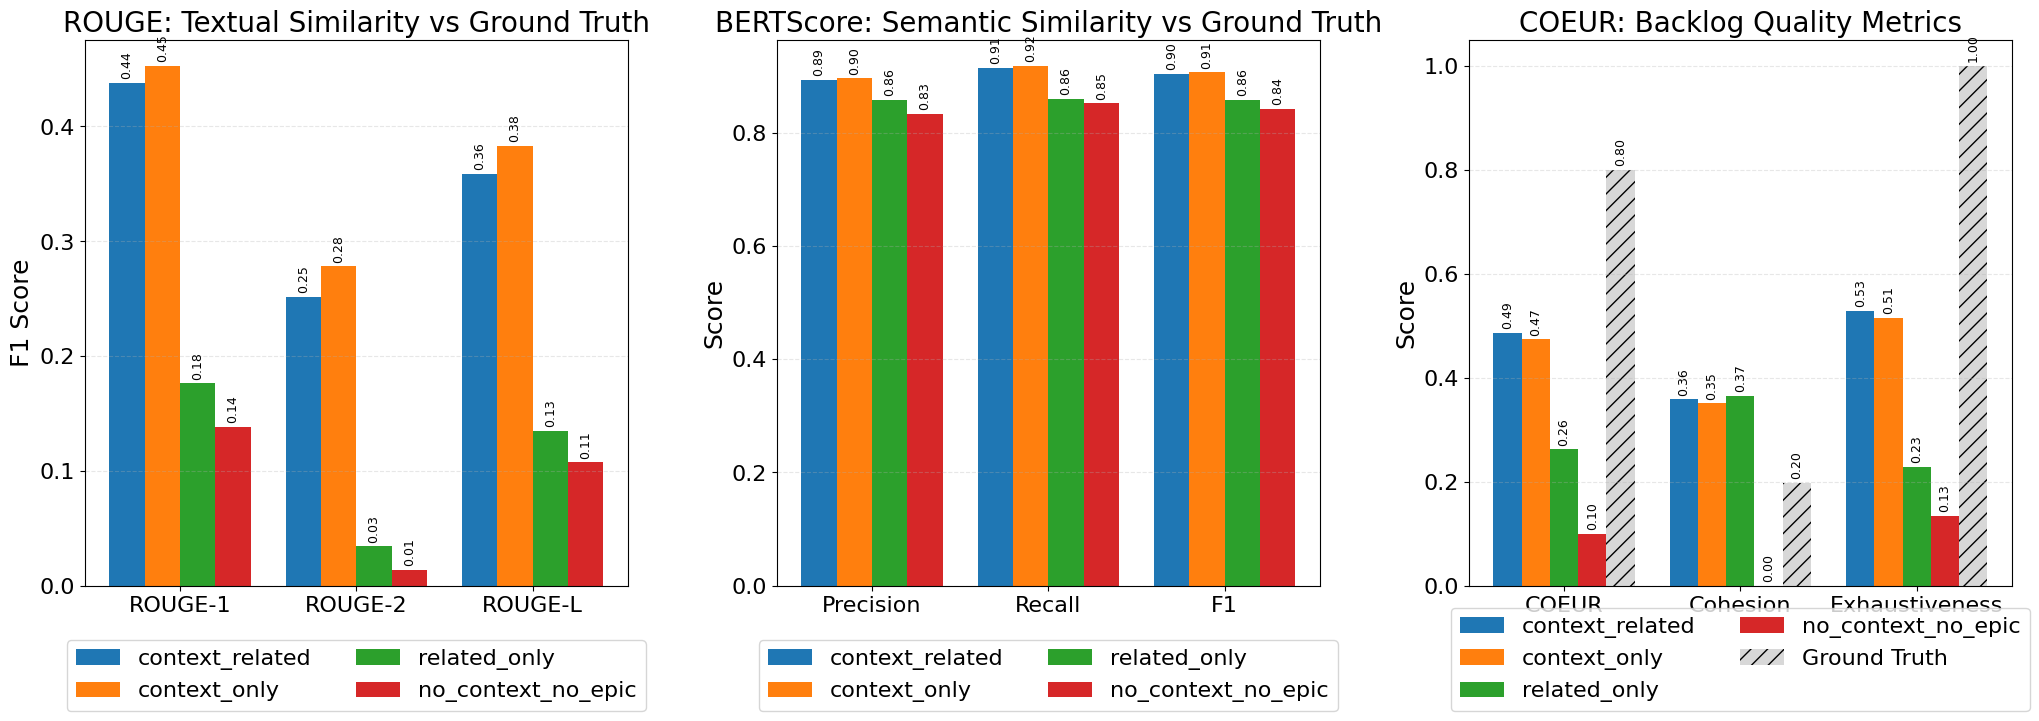

In [ ]:
strategies = {}
for name, prompt in prompts.items():
    B_pred = generate_B_alt(retro, llm,
                        prompt=prompt)
    strategies[name] = B_pred

_ = evaluate_and_compare(strategies, R_RETRO, B_true=B_RETRO,
                         sigma=SIGMA, l=L, lmbd=LMBD)

In [ ]:
save_strategies(strategies, prompts, "icl_retro", "mistral_small_22b")

Saved strategy 'context_related' to experiments/llm_validation/output/icl_retro/mistral_small_22b/strategy_context_related.json
Saved strategy 'context_only' to experiments/llm_validation/output/icl_retro/mistral_small_22b/strategy_context_only.json
Saved strategy 'related_only' to experiments/llm_validation/output/icl_retro/mistral_small_22b/strategy_related_only.json
Saved strategy 'no_context_no_epic' to experiments/llm_validation/output/icl_retro/mistral_small_22b/strategy_no_context_no_epic.json

✅ Experiment saved in: experiments/llm_validation/output/icl_retro/mistral_small_22b


PosixPath('experiments/llm_validation/output/icl_retro/mistral_small_22b')

### Alfred Dataset

In [ ]:
specs_path = os.path.join('datasets', 'alfred', 'alfred_specs.pdf')
backlog_path = os.path.join('datasets', 'alfred', 'alfred_backlog.csv')
R_ALFRED, B_ALFRED = coeur.load_data(ref_path=specs_path, cand_path=backlog_path, ref_mode="pdf", cand_mode="csv")

  0%|          | 0/110 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


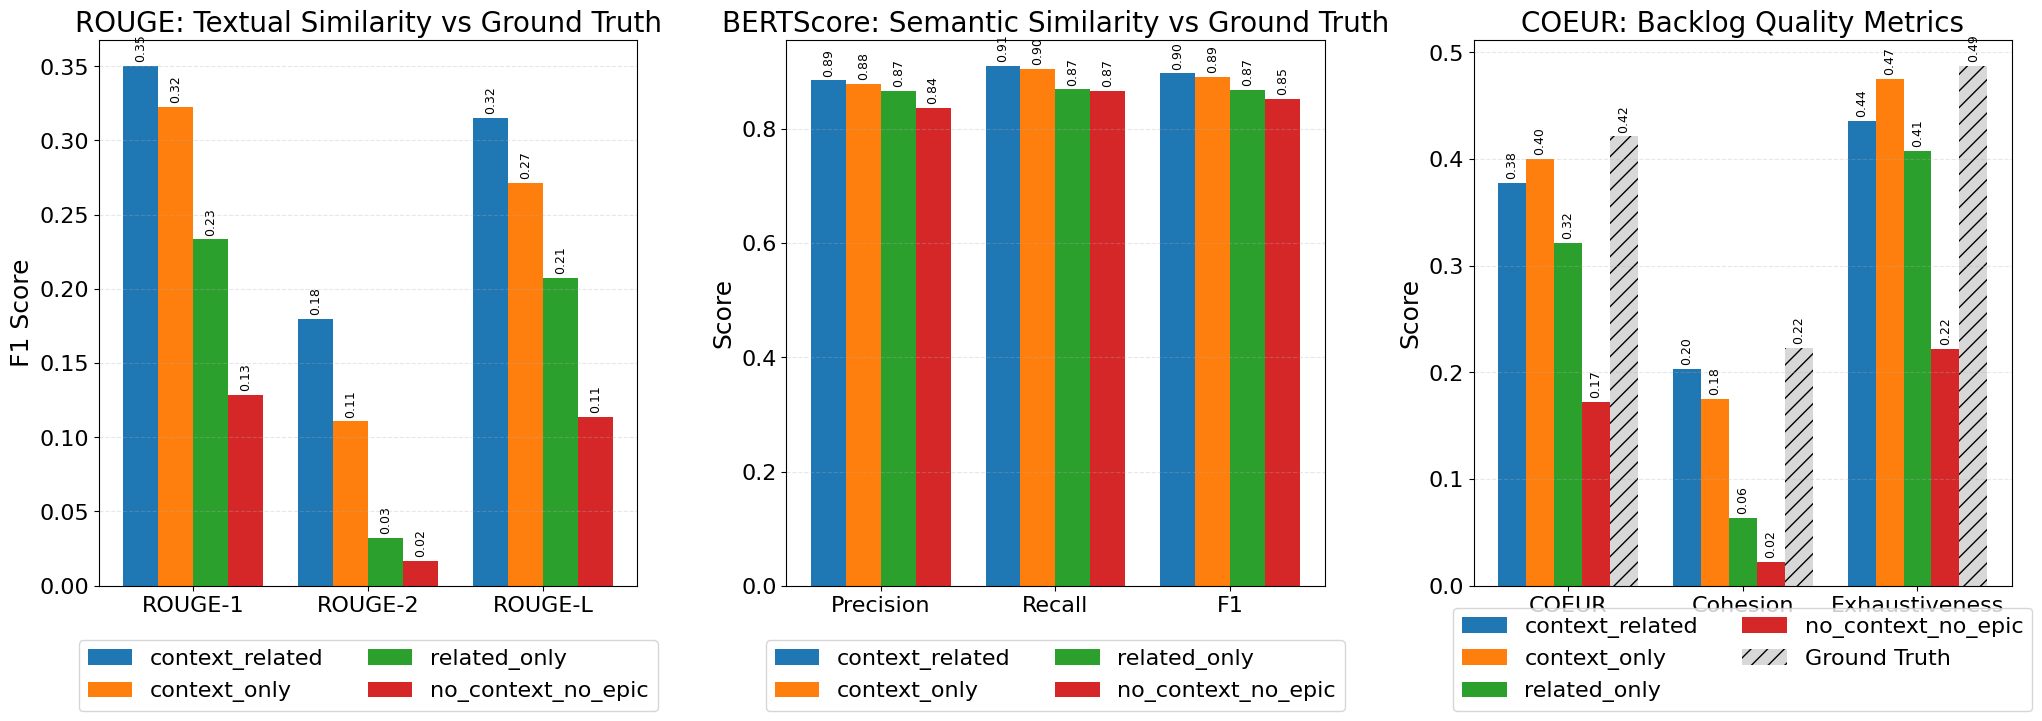

In [ ]:
strategies = {}
for name, prompt in prompts.items():
    B_pred = generate_B_alt(alfred, llm,
                        prompt=prompt)
    strategies[name] = B_pred

_ = evaluate_and_compare(strategies, R_ALFRED, B_true=B_ALFRED,
                         sigma=SIGMA, l=L, lmbd=LMBD)

In [ ]:
save_strategies(strategies, prompts, "icl_alfred", "mistral_small_22b")

Saved strategy 'context_related' to experiments/llm_validation/output/icl_alfred/mistral_small_22b/strategy_context_related.json
Saved strategy 'context_only' to experiments/llm_validation/output/icl_alfred/mistral_small_22b/strategy_context_only.json
Saved strategy 'related_only' to experiments/llm_validation/output/icl_alfred/mistral_small_22b/strategy_related_only.json
Saved strategy 'no_context_no_epic' to experiments/llm_validation/output/icl_alfred/mistral_small_22b/strategy_no_context_no_epic.json

✅ Experiment saved in: experiments/llm_validation/output/icl_alfred/mistral_small_22b


PosixPath('experiments/llm_validation/output/icl_alfred/mistral_small_22b')